# Feature Importance & Interpretability

This notebook provides global interpretability for the tuned drinking prediction model.
We focus on model-agnostic feature importance using permutation importance, computed on a held-out split.

## Imports & config

In [6]:
# --- Imports & project path setup (for notebooks) ---
import sys
from pathlib import Path

# Allow importing project modules from src/ when running from notebooks/
sys.path.insert(0, str((Path("..") / "src").resolve()))

import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.inspection import permutation_importance

from health_risk_ml.preprocessing import DomainCleaningTransformer

RANDOM_SEED = 42



## Load tuned artifact

In [5]:
ARTIFACTS_DIR = Path("../artifacts")
artifact_path = ARTIFACTS_DIR / "HistGradientBoosting_tuned.joblib"

artifact = joblib.load(artifact_path)

model_name = artifact["model_name"]
pipe = artifact["model"]              # full pipeline (preprocess + model)
best_params = artifact.get("best_params", {})
cv_best_f1 = artifact.get("cv_best_f1", None)

model_name, cv_best_f1, best_params


('HistGradientBoosting_tuned',
 0.7406385112320052,
 {'model__learning_rate': np.float64(0.08618101782710437),
  'model__max_depth': 7,
  'model__max_leaf_nodes': 29,
  'model__min_samples_leaf': 91})

## Load raw data + target

In [7]:
DATA_DIR = Path("../data")
RAW_DIR = DATA_DIR / "raw"
raw_path = RAW_DIR / "smoking_driking_dataset_Ver01.csv"

df = pd.read_csv(raw_path)

TARGET_COL = "DRK_YN"
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].map({"N": 0, "Y": 1})

assert not y.isna().any(), "Unexpected target values found."
X.shape, y.value_counts()


((991346, 23),
 DRK_YN
 0    495858
 1    495488
 Name: count, dtype: int64)

## Hold-out split for interpretability

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

# quick sanity check (pipeline should run)
y_proba = pipe.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_proba)

test_f1, test_roc_auc


(0.7432368960175886, 0.8239164457168024)

## Retrieve feature names after preprocessing

In [9]:
preprocess = pipe.named_steps["preprocess"]

# ColumnTransformer is the second step inside preprocess pipeline
ct = preprocess.named_steps["column_transform"]

feature_names = ct.get_feature_names_out()
len(feature_names), feature_names[:10]


(24,
 array(['BLDS', 'DBP', 'HDL_chole', 'LDL_chole', 'SBP', 'SGOT_ALT',
        'SGOT_AST', 'SMK_stat_type_cd', 'age', 'gamma_GTP'], dtype=object))

## Permutation importance

In [10]:
# Transform test set once (faster and stable)
X_test_transformed = preprocess.transform(X_test)

# Access underlying fitted model
estimator = pipe.named_steps["model"]

perm = permutation_importance(
    estimator,
    X_test_transformed,
    y_test,
    n_repeats=5,
    random_state=RANDOM_SEED,
    scoring="f1",
    n_jobs=1,
)

importances = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

importances.head(15)


,feature,importance_mean,importance_std
8,age,0.055926,0.000415
9,gamma_GTP,0.049884,0.000821
5,SGOT_ALT,0.023031,0.000284
7,SMK_stat_type_cd,0.018957,0.000672
2,HDL_chole,0.018124,0.000400
22,sex_Female,0.017372,0.000268
6,SGOT_AST,0.005232,0.000310
12,height,0.005119,0.000293
3,LDL_chole,0.002788,0.000104
18,triglyceride,0.001614,0.000160


## Plot top features

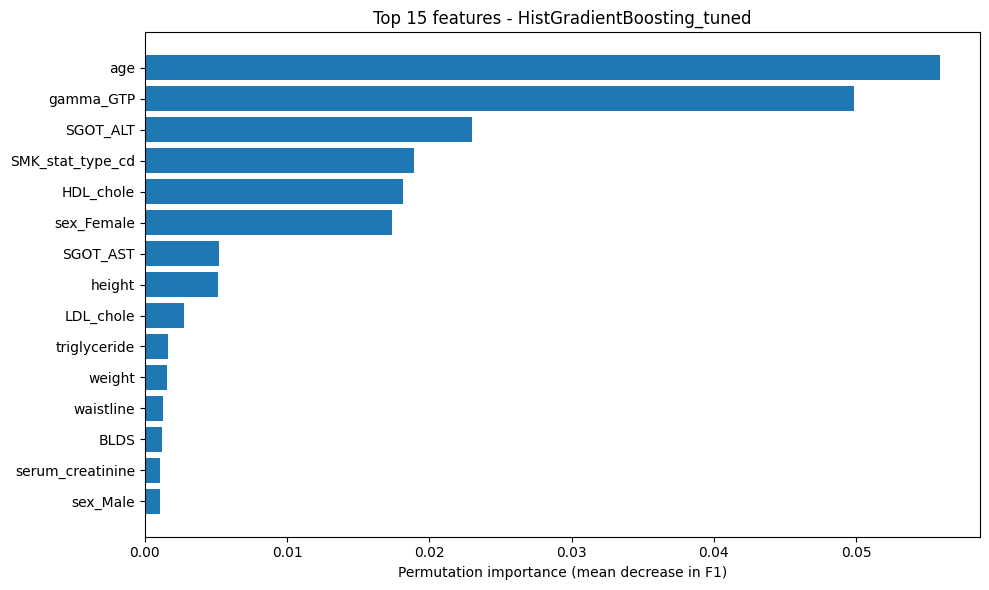

In [11]:
import matplotlib.pyplot as plt

top_n = 15
top = importances.head(top_n).iloc[::-1]  # reverse for horizontal bar chart

plt.figure(figsize=(10, 6))
plt.barh(top["feature"], top["importance_mean"])
plt.xlabel("Permutation importance (mean decrease in F1)")
plt.title(f"Top {top_n} features - {model_name}")
plt.tight_layout()
plt.show()


## Interpretation

The permutation importance results indicate that no single feature dominates the model’s predictions. Instead, the model relies on the cumulative contribution of multiple weak signals, which is expected given the multifactorial and behavioral nature of alcohol consumption.

Permutation importance is a model-agnostic technique that measures the impact of each feature on the F1-score by quantifying performance degradation when feature information is disrupted. The relatively small absolute importance values observed are therefore not a limitation of the method, but rather a reflection of the intrinsic complexity of the target variable.

Additionally, several input variables are correlated (e.g., metabolic markers and anthropometric measures), which can lead to shared importance across features. In such cases, permuting a single feature may result in a limited performance drop because related variables can partially compensate for the lost information.

Overall, these findings are consistent with the moderate predictive performance achieved by the supervised model and suggest the presence of heterogeneous and overlapping population subgroups. This observation motivates a complementary unsupervised analysis to further explore latent drinking profiles beyond a simple binary classification.

## Optional: Export importance table

In [12]:
OUT_DIR = Path("../results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = OUT_DIR / "feature_importance_permutation_f1.csv"

# Save permutation importance results for reuse in reports and Streamlit demo
importances.to_csv(out_path, index=False)

out_path


WindowsPath('../results/feature_importance_permutation_f1.csv')